## PHASE 1 & 2: EXPLORATION, DATA CLEANING AND STATISTICAL ANALYSIS

In [7]:
# Essential library imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.lines import Line2D
# Suppress technical warnings and file paths in output
import warnings
warnings.filterwarnings('ignore')

# Global environment configuration
pd.set_option("display.max_columns", None)

### 1. Exploratory Data Analysis (EDA) and Data Cleaning

In [8]:
df_flights = pd.read_csv("Customer Flight Activity.csv") # Load dataset

display(df_flights.head(2)) # Flights dataset exploration
print("=" * 100)

display(df_flights.tail(2))
print("=" * 100)

display(df_flights.sample(2))
print(f"The flights dataframe has {df_flights.shape[0]} rows and {df_flights.shape[1]} columns")

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
405622,999982,2018,12,0,0,0,0,0.0,0,0
405623,999986,2018,12,0,0,0,0,0.0,0,0


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
144519,596297,2017,9,0,0,0,0,0.0,0,0
200519,876062,2017,12,13,1,14,2842,284.0,0,0


The flights dataframe has 405624 rows and 10 columns


In [9]:
df_loyalty = pd.read_csv("Customer Loyalty History.csv")

display(df_loyalty.head(2)) # Loyalty dataset exploration
print("=" * 100)

display(df_loyalty.tail(2))
print("=" * 100)

display(df_loyalty.sample(2))
print(f"The loyalty dataframe has {df_loyalty.shape[0]} rows and {df_loyalty.shape[1]} columns")

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN
16736,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049.0,Married,Star,83325.38,Standard,2015,12,2016.0,8.0


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
6473,800499,Canada,New Brunswick,Fredericton,E3B 2H2,Female,Bachelor,72526.0,Divorced,Star,10676.59,2018 Promotion,2018,2,NaN,NaN
13805,230429,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,77816.0,Divorced,Star,5581.76,Standard,2012,9,NaN,NaN


The loyalty dataframe has 16737 rows and 16 columns


In [10]:
# Detailed information for Flights
print("--- Flights Data Summary Table ---")
flights_summary = pd.DataFrame({
    'Data Type': df_flights.dtypes,
    'Non-Null Count': df_flights.count(),
    'Null Count': df_flights.isnull().sum(),
    'Null Percentage (%)': (df_flights.isnull().sum() / len(df_flights)) * 100
}).round(2)
display(flights_summary)

--- Flights Data Summary Table ---


,Data Type,Non-Null Count,Null Count,Null Percentage (%)
Loyalty Number,int64,405624,0,0.0
Year,int64,405624,0,0.0
Month,int64,405624,0,0.0
Flights Booked,int64,405624,0,0.0
Flights with Companions,int64,405624,0,0.0
Total Flights,int64,405624,0,0.0
Distance,int64,405624,0,0.0
Points Accumulated,float64,405624,0,0.0
Points Redeemed,int64,405624,0,0.0
Dollar Cost Points Redeemed,int64,405624,0,0.0


In [11]:
# Detailed information for Loyalty
print("--- Loyalty Data Summary Table ---")
loyalty_summary = pd.DataFrame({
    'Data Type': df_loyalty.dtypes,
    'Non-Null Count': df_loyalty.count(),
    'Null Count': df_loyalty.isnull().sum(),
    'Null Percentage (%)': (df_loyalty.isnull().sum() / len(df_loyalty)) * 100
}).round(2)
display(loyalty_summary)

--- Loyalty Data Summary Table ---


,Data Type,Non-Null Count,Null Count,Null Percentage (%)
Loyalty Number,int64,16737,0,0.00
Country,str,16737,0,0.00
Province,str,16737,0,0.00
City,str,16737,0,0.00
Postal Code,str,16737,0,0.00
Gender,str,16737,0,0.00
Education,str,16737,0,0.00
Salary,float64,12499,4238,25.32
Marital Status,str,16737,0,0.00
Loyalty Card,str,16737,0,0.00


### Observations & Cleaning Strategy

Based on the exploratory data analysis, the following technical strategies have been defined for data cleaning and merging:
 
### **Flights Dataset:**
 * **Identifiers:** Retain `loyalty_number` as `int64` to optimize memory and join performance. As a unique ID, statistical aggregations (mean, median) are not applicable.
 * **Data Integrity & Valid Zeros:** Although there are no null values, we must verify that `loyalty_number`, `year`, and `month` are strictly > 0 to rule out corrupt records. Zeros in flight metrics (e.g., flights booked) represent valid inactive months for users and must be strictly preserved to avoid distorting the temporal behavior.
 * **Temporal Engineering:** Combine the `year` and `month` integer columns into a unified `datetime` feature (`flight_date`) for proper time-series analysis.
 * **Type Consistency:** Cast `points_redeemed` and `dollar_cost_points_redeemed` to `float` to maintain consistency with the `points_accumulated` format.

### **Loyalty Dataset:**
 * **Relational Key:** `loyalty_number` remains an `int64` and will serve as the primary key for joining both dataframes.
 * **Categorical Audit:** String columns will be audited to verify the absence of pseudo-duplicate categories. 
 * **Missing Data & Anomalies (Salary):**  Approximately 25% of `salary` data is missing. We must first identify and neutralize anomalies (e.g., negative salaries) before applying median imputation to avoid skewing the distribution.
 * **Temporal Engineering:** Combine enrollment and cancellation periods into unified `enrollment_date` and `cancellation_date` columns.
 * **Temporal Features & Cancellations (MNAR Strategy):** Over 87% of cancellation data is null, indicating active memberships (Missing Not At Random). To extract this business value, we will create a boolean `is_active` feature. Then, we will generate a unified `cancellation_date` (leaving active users as `NaT`), and finally, drop the original, redundant cancellation year and month columns to optimize memory.

#### Global Schema Standardization (columns)

In [12]:
def standardize_headers(df): # Converts all column names to snake_case format for consistency
    original_cols = df.columns.tolist()
    df.columns = [col.lower().replace(" ", "_") for col in df.columns]
    print(f"Headers standardized: {len(original_cols)} columns processed.")
    return df

In [13]:
# Apply column standardization to both datasets to ensure a uniform schema
df_flights = standardize_headers(df_flights)
df_loyalty = standardize_headers(df_loyalty)

print("\n--- Standardized Flights Headers ---")
print(df_flights.columns.tolist())

print("\n--- Standardized Loyalty Headers ---")
print(df_loyalty.columns.tolist())

Headers standardized: 10 columns processed.
Headers standardized: 16 columns processed.

--- Standardized Flights Headers ---
['loyalty_number', 'year', 'month', 'flights_booked', 'flights_with_companions', 'total_flights', 'distance', 'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed']

--- Standardized Loyalty Headers ---
['loyalty_number', 'country', 'province', 'city', 'postal_code', 'gender', 'education', 'salary', 'marital_status', 'loyalty_card', 'clv', 'enrollment_type', 'enrollment_year', 'enrollment_month', 'cancellation_year', 'cancellation_month']


In [14]:
# Combines separate year and month columns into a single unified datetime object.
def create_datetime_feature(df, year_col, month_col, new_name, position=None): # Specifying the insertion position.
    # Create a temporary DataFrame with standardized names for pd.to_datetime
    temp_df = df[[year_col, month_col]].rename(columns={year_col: 'year', month_col: 'month'})
    # Convert to datetime (NaNs will correctly result in NaT - Not a Time)
    new_series = pd.to_datetime(temp_df.assign(day=1)).dt.to_period('M')  # This removes the 'day' component visually while retaining time-series capabilities
    # Insert at specific position if provided, otherwise append to the end
    if position is not None:
        df.insert(position, new_name, new_series)
    else:
        df[new_name] = new_series

    df.drop(columns=[year_col, month_col], inplace=True) # Drop redundant source columns
    return df

In [15]:
df_flights = create_datetime_feature(df_flights, 'year', 'month', 'flight_date', position=2) # Create flight_date

# Create enrollment_date and cancellation_date
df_loyalty = create_datetime_feature(df_loyalty, 'enrollment_year', 'enrollment_month', 'enrollment_date') 
df_loyalty = create_datetime_feature(df_loyalty, 'cancellation_year', 'cancellation_month', 'cancellation_date')

print("Temporal Engineering ✔️: Combine the `year` and `month` integer columns into a unified `datetime`check: created for both datasets.")

Temporal Engineering ✔️: Combine the `year` and `month` integer columns into a unified `datetime`check: created for both datasets.


In [16]:
df_loyalty.sample(5)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_date,cancellation_date
2878,337980,Canada,Ontario,Toronto,M2M 6J7,Male,College,NaN,Married,Aurora,9155.24,Standard,2014-12,NaT
8766,127350,Canada,Ontario,London,M5B 3E4,Male,High School or Below,51775.0,Divorced,Nova,10614.64,Standard,2014-04,NaT
14722,924217,Canada,Ontario,Sudbury,M5V 1G5,Male,College,NaN,Single,Star,7685.65,Standard,2018-11,NaT
290,884530,Canada,British Columbia,Vancouver,V5R 1W3,Female,High School or Below,61040.0,Married,Star,4381.88,Standard,2018-07,NaT
2315,439350,Canada,Ontario,Kingston,M9K 2P4,Female,College,NaN,Single,Aurora,7912.13,Standard,2013-02,NaT


In [17]:
df_flights.sample(5)

,loyalty_number,flight_date,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
48635,888506,2017-03,15,6,21,1911,191.0,0,0
183381,863108,2017-11,8,0,8,1384,138.0,0,0
265283,670215,2018-04,12,0,12,2796,418.5,0,0
365057,639117,2018-10,0,0,0,0,0.0,0,0
346332,543852,2018-09,0,0,0,0,0.0,0,0


#### Categorical Data Cleaning 

In [18]:
def get_categorical_columns(df): # Returns a list of column names with 'object' data type.
    return df.select_dtypes('object').columns.tolist()

def show_unique_categories(df, columns):
    for col in columns:
        uniques = df[col].unique() # Prints unique values for categorical columns and verifies data consistency. 
        print(f"Unique in '{col}': {uniques}")
        
        # Validation Logic: compare current uniques vs. normalized uniques
        normalized_count = df[col].astype(str).str.lower().str.strip().nunique()
        
        if len(uniques) == normalized_count:
            print(f"Consistency Check: All categories are unique. No casing or spacing duplicates found.")
        else:
            print(f"Consistency Check: Pseudo-duplicates detected. Normalization (.str.lower().str.strip()) would be required.")
        print("-" * 30)

In [19]:
categorical_cols = get_categorical_columns(df_loyalty)

print("--- CATEGORICAL DATA AUDIT ✔️ ---") 
show_unique_categories(df_loyalty, categorical_cols)

--- CATEGORICAL DATA AUDIT ✔️ ---
Unique in 'country': <StringArray>
['Canada']
Length: 1, dtype: str
Consistency Check: All categories are unique. No casing or spacing duplicates found.
------------------------------
Unique in 'province': <StringArray>
[             'Ontario',              'Alberta',     'British Columbia',
               'Quebec',                'Yukon',        'New Brunswick',
             'Manitoba',          'Nova Scotia',         'Saskatchewan',
         'Newfoundland', 'Prince Edward Island']
Length: 11, dtype: str
Consistency Check: All categories are unique. No casing or spacing duplicates found.
------------------------------
Unique in 'city': <StringArray>
[       'Toronto',       'Edmonton',      'Vancouver',           'Hull',
     'Whitehorse',        'Trenton',       'Montreal',   'Dawson Creek',
    'Quebec City',    'Fredericton',         'Ottawa',      'Tremblant',
        'Calgary',    'Thunder Bay',       'Whistler',    'Peace River',
       'Winnipe

In [20]:
df_loyalty.sample(2)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_date,cancellation_date
15500,744406,Canada,Quebec,Hull,J8Y 3Z5,Female,Bachelor,52489.0,Married,Star,5497.66,2018 Promotion,2018-03,NaT
10065,934235,Canada,Saskatchewan,Regina,S1J 3C5,Female,High School or Below,67124.0,Divorced,Star,2279.70,Standard,2016-04,NaT


#### Numerical Data Cleaning 

In [21]:
# Ensures that every record has a valid identifier and a non-null temporal reference.
invalid_records = df_flights[(df_flights['loyalty_number'] <= 0) | (df_flights['flight_date'].isnull())]
print(f"Data Integrity & Valid Zeros ✔️: {len(invalid_records)} invalid records found (ID or Date <= 0).")

Data Integrity & Valid Zeros ✔️: 0 invalid records found (ID or Date <= 0).


In [22]:
# Type Casting point metrics: Harmonizing integers to floats for consistency
df_flights['points_redeemed'] = df_flights['points_redeemed'].astype(float)
df_flights['dollar_cost_points_redeemed'] = df_flights['dollar_cost_points_redeemed'].astype(float)

print(f"Type Consistency ✔️.\n"
      f"{df_flights[[ 'points_accumulated' , 'points_redeemed', 'dollar_cost_points_redeemed']].dtypes}")

Type Consistency ✔️.
points_accumulated             float64
points_redeemed                float64
dollar_cost_points_redeemed    float64
dtype: object


In [23]:
# Advanced Cleaning: Grouped Salary Imputation

# Neutralize negatives in salary
df_loyalty.loc[df_loyalty['salary'] < 0, 'salary'] = np.nan

# Create a boolean flag BEFORE imputation to track which salaries were originally null.
salary_idx = df_loyalty.columns.get_loc('salary')
df_loyalty.insert(salary_idx + 1, 'is_salary_imputed', df_loyalty['salary'].isnull()) # Insert it exactly after the 'salary' column so they stay logically grouped together.

# Grouped Imputation Logic: filling nulls based on Education and Loyalty Card segments
df_loyalty['salary'] = df_loyalty.groupby(['education', 'loyalty_card'])['salary'].transform(
    lambda x: x.fillna(x.median())) # This approach preserves the natural variance of the data for general analysis.

# Final safety fallback
if df_loyalty['salary'].isnull().any():
    df_loyalty['salary'] = df_loyalty['salary'].fillna(df_loyalty['salary'].median())

# Verification Audit Table
print("--- Missing Data & Anomalies (Salary) Verification ---")
imputation_audit = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Mode', 'Remaining Negatives', 'Remaining Nulls', 'Imputed Records'],
    'Value': [
        df_loyalty['salary'].mean(),
        df_loyalty['salary'].median(),
        df_loyalty['salary'].mode()[0],
        len(df_loyalty[df_loyalty['salary'] < 0]),
        df_loyalty['salary'].isnull().sum(),
        df_loyalty['is_salary_imputed'].sum()
    ]
}).round(2)
display(imputation_audit)

--- Missing Data & Anomalies (Salary) Verification ---


,Metric,Value
0,Mean,77907.31
1,Median,73455.00
2,Mode,73455.00
3,Remaining Negatives,0.00
4,Remaining Nulls,0.00
5,Imputed Records,4258.00


##### **Post-Imputation Audit Conclusions**
* **Imputation vs. Deletion Rationale:** Dropping records with missing salaries was explicitly rejected. Doing so would have meant discarding roughly 25% of the dataset, losing highly valuable associated information such as flight activity, redemption behavior, and other demographic traits. Imputation allows us to retain this critical multi-dimensional data.
* **Grouped Logic Validation:** The resulting metrics (Mean: ~77907.31, Median: 73455.00) reflect the values after the segmented imputation.
* **Effect on Central Tendency:** The global mean decreased from ~79429 (global imputation) to 77907.31. This is a significant improvement, indicating that imputing based on socio-economic proxies (Education + Card) leads to a more realistic and less inflated distribution.
* **Mode/Median Relationship:** The mode matching the global median (73455.00) suggests that the segments with this median had a higher density of missing values, or it was the final safety fallback value.
* **Integrity Green Light:** Zero remaining negatives and nulls confirm the column is now 100% clean and statistically valid for Phase 2.

In [24]:
# MNAR Strategy: Interpreting null cancellation dates as Active Memberships.
df_loyalty['is_active'] = df_loyalty['cancellation_date'].isnull()


null_count = df_loyalty['cancellation_date'].isnull().sum() # Confirming nulls match our 'is_active' logic
active_count = df_loyalty['is_active'].sum()

print(f"📅 Active status flag prepared.\n"
      f" - Total nulls in cancellation_date (Raw): {null_count}\n"
      f" - Total customers marked as Active: {active_count}\n"
      f" (Note: Nulls are preserved as 'NaT' because they represent active users)")

print("\n Temporal Features & Cancellations (MNAR Strategy) ✔️")
display(df_loyalty[['loyalty_number', 'enrollment_date', 'cancellation_date', 'is_active']].sample(2))

📅 Active status flag prepared.
 - Total nulls in cancellation_date (Raw): 14670
 - Total customers marked as Active: 14670
 (Note: Nulls are preserved as 'NaT' because they represent active users)

 Temporal Features & Cancellations (MNAR Strategy) ✔️


,loyalty_number,enrollment_date,cancellation_date,is_active
11823,745454,2018-07,NaT,True
11373,618824,2015-10,NaT,True


### Observations & Merging Strategy
* **Join Operation:** Perform a `LEFT JOIN` using the Flights dataset as the left table and Loyalty as the right table on `loyalty_number`. This preserves every transactional record while broadcasting the demographic attributes to each corresponding flight month.

In [25]:
df_merged = pd.merge(df_flights, df_loyalty, on='loyalty_number', how='left')

print(f"Final Merged Dataset - Rows: {df_merged.shape[0]} | Columns: {df_merged.shape[1]}")
print("\nPost-Merge Null Verification:")
# Note: cancellation_date nulls are expected and represent ACTIVE customers.
display(df_merged.isnull().sum()[df_merged.isnull().sum()>0])

Final Merged Dataset - Rows: 405624 | Columns: 24

Post-Merge Null Verification:


cancellation_date    355560
dtype: int64

In [26]:
# Exporting cleaned and merged data for the next phase
df_merged.to_csv("customer_loyalty_cleaned.csv", index=False)
print(f"✔️ Dataset merged and exported to 'customer_loyalty_cleaned.csv' ({df_merged.shape[0]} rows).")

✔️ Dataset merged and exported to 'customer_loyalty_cleaned.csv' (405624 rows).


### 2. Statistical Analysis

In [27]:
# Obtaining dynamic information about all columns
print("--- Merged Dataset Metadata Information ---")
df_merged.info()

--- Merged Dataset Metadata Information ---
<class 'pandas.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype    
---  ------                       --------------   -----    
 0   loyalty_number               405624 non-null  int64    
 1   flight_date                  405624 non-null  period[M]
 2   flights_booked               405624 non-null  int64    
 3   flights_with_companions      405624 non-null  int64    
 4   total_flights                405624 non-null  int64    
 5   distance                     405624 non-null  int64    
 6   points_accumulated           405624 non-null  float64  
 7   points_redeemed              405624 non-null  float64  
 8   dollar_cost_points_redeemed  405624 non-null  float64  
 9   country                      405624 non-null  str      
 10  province                     405624 non-null  str      
 11  city                         405624 non-null  str      
 1

#### 2.1 Numerical Variables Analysis

In [28]:
# Obtaining detailed information for all numerical columns (int and float)
numeric_data = df_merged.select_dtypes(include="number")

numeric_summary = pd.DataFrame({
    'Data Type': numeric_data.dtypes,
    'Total Rows': [len(df_merged)] * len(numeric_data.columns),
    'Data Present': numeric_data.count(),
    'Null Data': numeric_data.isnull().sum(),
    'Null Percentage (%)': (numeric_data.isnull().sum() / len(df_merged)) * 100
}).round(2)

print("--- Detailed Summary of All Numerical Columns ---")
display(numeric_summary)

--- Detailed Summary of All Numerical Columns ---


,Data Type,Total Rows,Data Present,Null Data,Null Percentage (%)
loyalty_number,int64,405624,405624,0,0.0
flights_booked,int64,405624,405624,0,0.0
flights_with_companions,int64,405624,405624,0,0.0
total_flights,int64,405624,405624,0,0.0
distance,int64,405624,405624,0,0.0
points_accumulated,float64,405624,405624,0,0.0
points_redeemed,float64,405624,405624,0,0.0
dollar_cost_points_redeemed,float64,405624,405624,0,0.0
salary,float64,405624,405624,0,0.0
clv,float64,405624,405624,0,0.0


In [29]:
# Exclude 'loyalty_number' only from the display and statistical calculations
print("\n--- Descriptive Statistics for Numerical Features (Excluding IDs) ---")
stats_data = numeric_data.drop(columns=['loyalty_number'], errors='ignore') # Create a temporary subset without the ID for calculation

stats_summary = stats_data.describe().T
stats_summary['mode'] = stats_data.mode().iloc[0]
display(stats_summary[['mean', '50%', 'mode', 'std', 'min', 'max']].rename(columns={'50%': 'median'}))


--- Descriptive Statistics for Numerical Features (Excluding IDs) ---


,mean,median,mode,std,min,max
flights_booked,4.115052,1.00,0.00,5.225518,0.00,21.00
flights_with_companions,1.031805,0.00,0.00,2.076869,0.00,11.00
total_flights,5.146858,1.00,0.00,6.521227,0.00,32.00
distance,1208.880059,488.00,0.00,1433.155320,0.00,6293.00
points_accumulated,123.692721,50.00,0.00,146.599831,0.00,676.50
points_redeemed,30.696872,0.00,0.00,125.486049,0.00,876.00
dollar_cost_points_redeemed,2.484503,0.00,0.00,10.150038,0.00,71.00
salary,77923.935329,73455.00,73455.00,30090.735738,15609.00,407228.00
clv,7991.976226,5776.34,3873.65,6863.663857,1898.01,83325.38


#### **Mathematical Insights & Hypothesis Correction**

##### **1. Positive Skewness:**
 - **Analysis:** Metrics like `flights_booked` and `distance` show a Mean significantly higher than the Median (e.g., Mean 4.1 vs Median 1.0).
 - **Correction:** The Median (1.0) is the most reliable measure for the "typical" customer. The Mean is distorted by high-activity outliers.
##### **2. Zero-Inflation:**
 - **Observation:** The Mode for most activity columns is 0.00. This confirms a high "dormancy" rate where the most frequent behavior is not booking a flight.
##### **3. Standard Deviation (Volatility):**
 - **Observation:** `points_redeemed` shows a `std` (125.48) that is 4x the Mean. This indicates that point redemption is sporadic and concentrated in few users.
##### **4. Salary Distribution & Early Hypothesis:**
 - **Observation:** The salary data is now more representative, with peaks reflecting the anchors of specific socio-economic segments (Education and Card Tier). Furthermore, the slight increase in mean salary after merging initially suggests that wealthier users might fly more frequently.
 - **Caution:** This is merely a preliminary assumption based on data weighting. We must rigorously test this hypothesis in the upcoming correlation phase to verify if wealth genuinely drives flight activity.

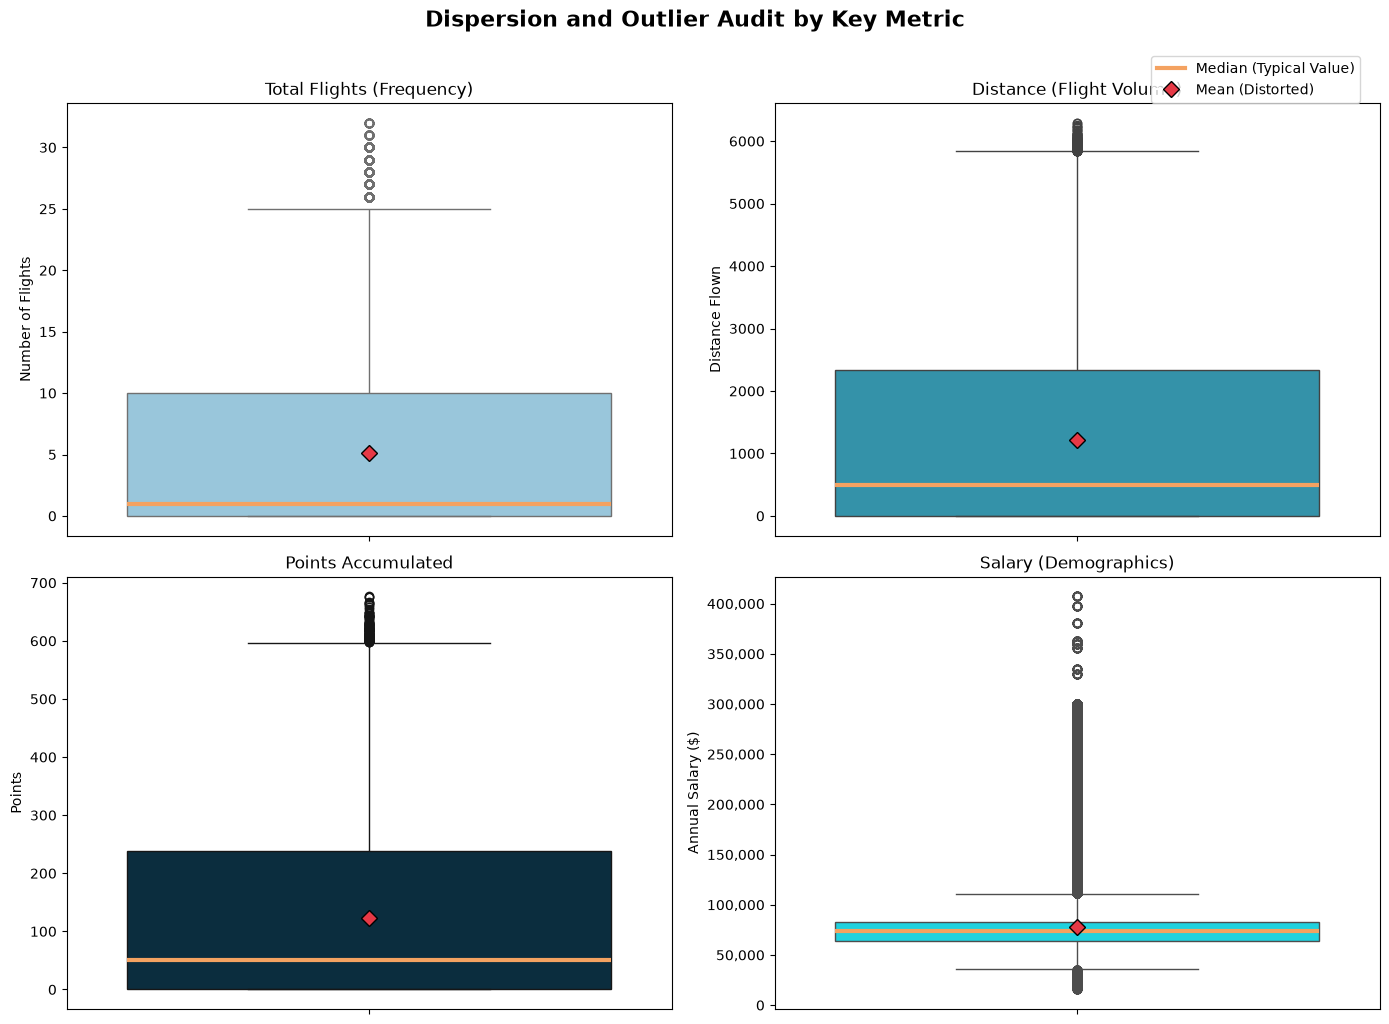

In [30]:
# Visual Outlier Audit with independent scales

fig, axes = plt.subplots(2, 2, figsize=(14, 10)) # Setting up a 2x2 grid to provide independent Y-axes for variables with different scales
fig.suptitle("Dispersion and Outlier Audit by Key Metric", fontsize=16, fontweight='bold', y=1.02)

# Style dictionaries for Mean and Median markers
mean_style = {"marker":"D", "markerfacecolor":"#E63946", "markeredgecolor":"black", "markersize":8}
median_style = {"color":"#F4A261", "linewidth":3}

# Plot 1: Total Flights (Low Scale 0-50)
sns.boxplot(ax=axes[0, 0], data=df_merged, y='total_flights', color="#8ECAE6", 
            showmeans=True, meanprops=mean_style, medianprops=median_style)
axes[0, 0].set_title("Total Flights (Frequency)")
axes[0, 0].set_ylabel("Number of Flights")

# Plot 2: Distance (Mid Scale 0-10,000)
sns.boxplot(ax=axes[0, 1], data=df_merged, y='distance', color="#219EBC", 
            showmeans=True, meanprops=mean_style, medianprops=median_style)
axes[0, 1].set_title("Distance (Flight Volume)")
axes[0, 1].set_ylabel("Distance Flown")

# Plot 3: Points Accumulated (Program Value)
sns.boxplot(ax=axes[1, 0], data=df_merged, y='points_accumulated', color="#023047", 
            showmeans=True, meanprops=mean_style, medianprops=median_style)
axes[1, 0].set_title("Points Accumulated")
axes[1, 0].set_ylabel("Points")

# Plot 4: Salary (High Scale Demographics)
sns.boxplot(ax=axes[1, 1], data=df_merged, y='salary', color="#00EEFF", 
            showmeans=True, meanprops=mean_style, medianprops=median_style)
axes[1, 1].set_title("Salary (Demographics)")
axes[1, 1].set_ylabel("Annual Salary ($)")
axes[1, 1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # Add commas to salary

# Adding a global custom legend
custom_lines = [
    Line2D([0], [0], color='#F4A261', lw=3),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#E63946', markeredgecolor='black', markersize=8)
]
fig.legend(custom_lines, ['Median (Typical Value)', 'Mean (Distorted)'], loc='upper right', bbox_to_anchor=(0.98, 0.98))

plt.tight_layout()
plt.show()


#### **Analytical Discovery** 
* The boxplots revealed extreme positive skewness across all flight metrics. The dataset is heavily driven by a tiny fraction of "elite" users (outliers) who fly massively, while the typical user is heavily inactive (Mode = 0)

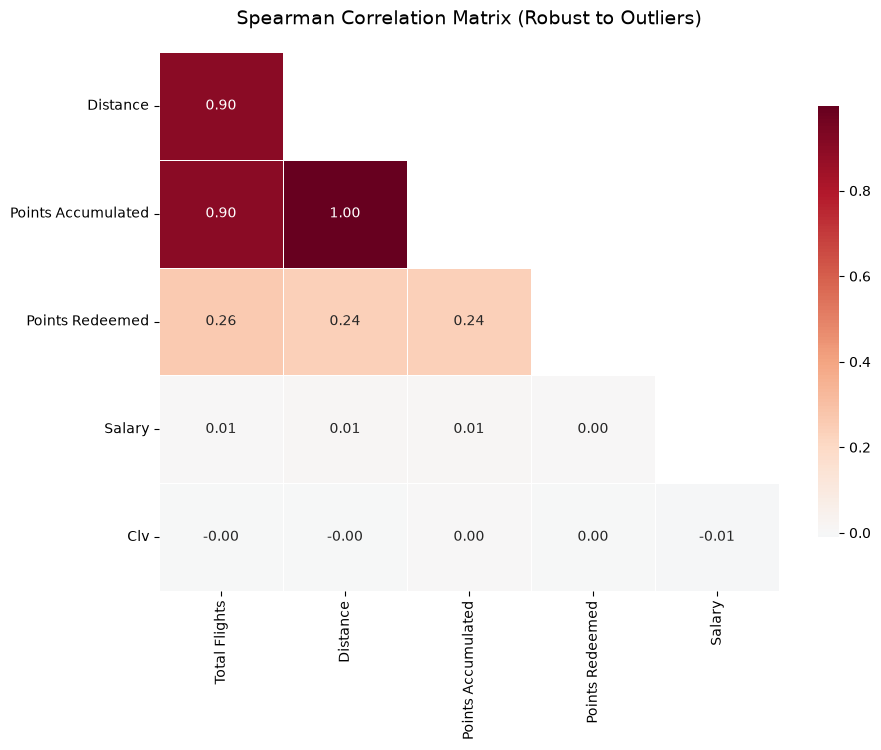

In [32]:
# Linear Correlation & Core Relationships

feature_cols = ['total_flights', 'distance', 'points_accumulated', 'points_redeemed', 'salary', 'clv' ] 

corr_data = df_merged[feature_cols].copy()
corr_data.columns = [c.replace('_', ' ').title() for c in corr_data.columns]

corr_data = df_merged[feature_cols].copy()
corr_data.columns = [c.replace('_', ' ').title() for c in corr_data.columns]

# Since our data is non-normal, heavily skewed, and full of outliers, 
corr_matrix = corr_data.corr(method='spearman') # Pearson would falsely inflate correlations. Spearman uses monotonic ranking.

mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Create a mask to hide the upper triangle and the diagonal

corr_matrix_trimmed = corr_matrix.iloc[1:, :-1] # Slice the matrix and mask to remove the empty top row and right column
mask_trimmed = mask[1:, :-1]

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix_trimmed, mask=mask_trimmed, annot=True, cmap='RdBu_r', fmt=".2f", center=0,
            linewidths=0.5, cbar_kws={"shrink": .8})
plt.title("Spearman Correlation Matrix (Robust to Outliers)", fontsize=14, pad=20)
plt.show()

#### **Analytical Discovery** 
* The correlation matrix debunked the intuitive assumption that higher salaries lead to more flights. The correlation between Salary and Total Flights or CLV is virtually nonexistent (~0.00).
* Conversely, the highest correlations found are strictly operational: Distance vs. Points Accumulated (1) and Total Flights vs. Distance (0.90), which perfectly sets the stage for the program's mechanical rules explored next.

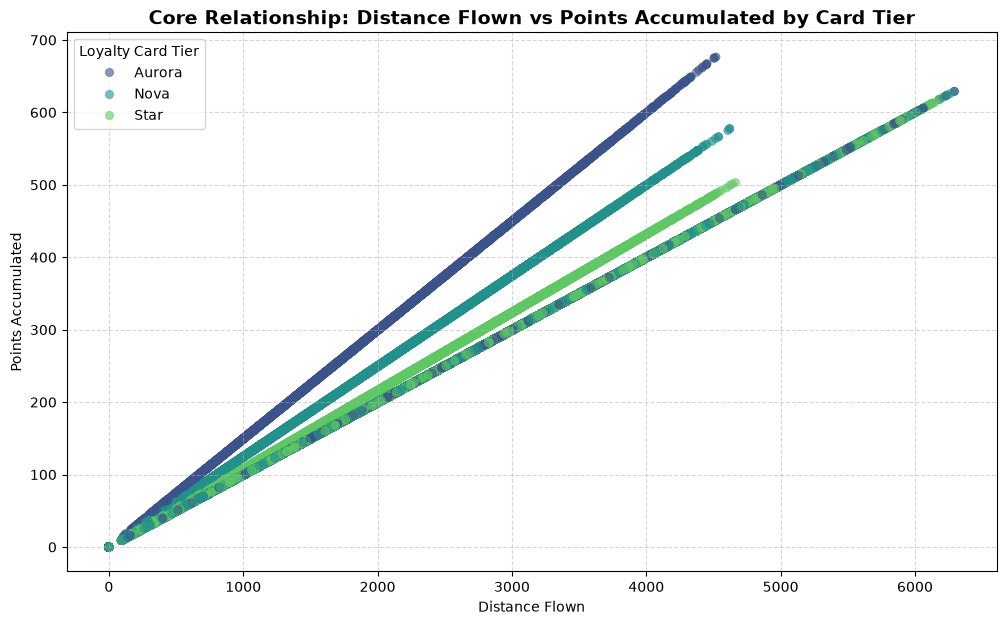

In [33]:
# Specific Business Relationship: Distance vs Points by Loyalty Tier
# This visualizes the actual economy of the loyalty program.
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_merged, x='distance', y='points_accumulated', hue='loyalty_card', 
                palette='viridis', alpha=0.6, edgecolor=None)
plt.title("Core Relationship: Distance Flown vs Points Accumulated by Card Tier", fontsize=14, fontweight='bold')
plt.xlabel("Distance Flown")
plt.ylabel("Points Accumulated")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Loyalty Card Tier")
plt.show()

#### **Analytical Discovery** 
* The scatterplot proves the loyalty program operates strictly on tier multipliers with zero random point issuance. The distance flown is the absolute and mathematically rigid predictor of points accumulated.

#### 2.2 Categorical Variables Analysis

In [34]:
# Obtaining detailed information for all numerical columns (object, bool and datetime)
categoric_data = df_merged.select_dtypes(include=["object", "bool", "period[M]"])

categoric_summary = pd.DataFrame({
    'Data Type': categoric_data.dtypes,
    'Total Rows': [len(df_merged)] * len(categoric_data.columns),
    'Data Present': categoric_data.count(),
    'Null Data': categoric_data.isnull().sum(),
    'Null Percentage (%)': (categoric_data.isnull().sum() / len(df_merged)) * 100
}).round(2)

print("--- Detailed Summary of All Categorical & Non-Numeric Columns ---")
display(categoric_summary)

--- Detailed Summary of All Categorical & Non-Numeric Columns ---


,Data Type,Total Rows,Data Present,Null Data,Null Percentage (%)
flight_date,period[M],405624,405624,0,0.00
country,str,405624,405624,0,0.00
province,str,405624,405624,0,0.00
city,str,405624,405624,0,0.00
postal_code,str,405624,405624,0,0.00
gender,str,405624,405624,0,0.00
education,str,405624,405624,0,0.00
is_salary_imputed,bool,405624,405624,0,0.00
marital_status,str,405624,405624,0,0.00
loyalty_card,str,405624,405624,0,0.00


In [35]:
# Identifying key categorical columns for frequency analysis
categorical_cols = ['education', 'loyalty_card', 'marital_status', 'gender', 'is_active', 'province']

print("--- Frequency Distribution: Selected Features ---")
for col in categorical_cols:
    if col in df_merged.columns:
        freq = df_merged[col].value_counts(normalize=True) * 100
        print(f"\nDistribution for {col.upper()}:")
        display(freq.to_frame(name='Percentage (%)').round(2))

--- Frequency Distribution: Selected Features ---

Distribution for EDUCATION:


,Percentage (%)
education,
Bachelor,62.56
College,25.31
High School or Below,4.69
Doctor,4.40
Master,3.04



Distribution for LOYALTY_CARD:


,Percentage (%)
loyalty_card,
Star,45.42
Nova,33.92
Aurora,20.67



Distribution for MARITAL_STATUS:


...

,Percentage (%)
gender,
Female,50.2
Male,49.8



Distribution for IS_ACTIVE:


,Percentage (%)
is_active,
True,87.66
False,12.34



Distribution for PROVINCE:


,Percentage (%)
province,
Ontario,32.27
British Columbia,26.34
Quebec,19.71
Alberta,5.77
Manitoba,3.94
New Brunswick,3.80
Nova Scotia,3.10
Saskatchewan,2.45
Newfoundland,1.56


#### **Analytical Discovery** 
Based on the frequency distributions, we can outline the typical customer persona and the overall health of the program:

* **Education:** The core demographic is highly educated, with **62.56%** of members holding a Bachelor's degree.
* **Marital Status:** The majority of the user base is **Married (58.13%)**, which provides an excellent opportunity to promote companion flight offers or family vacation packages.
* **Gender Equality:** The loyalty program has achieved a perfectly balanced demographic split (**50.2% Female, 49.8% Male**), indicating that marketing messaging does not need to heavily skew toward one specific gender.
* **Churn Rate & Health:** The program is extremely healthy with a massive **87.66% active retention rate**. Only **12.34%** of members have canceled their subscriptions, suggesting strong loyalty (or high passive retention).
* **Geographic Opportunity:** By tracking the `province` distributions, the marketing team can pinpoint exactly where the user base is concentrated. This geo-data is critical for launching targeted, localized marketing campaigns aimed at stimulating flight frequency among the dormant segments of the user base.

## **Overall Business Conclusion for Phase 2**

* The combined mathematical and demographic analysis paints a clear picture of a "Long Tail" loyalty program. 
* The airline relies on a highly stable, educated, and loyal customer base that, paradoxically, rarely flies on a month-to-month basis (Mode = 0). 
* Simultaneously, a microscopic elite fraction of users generates the vast majority of the flight volume and Customer Lifetime Value (CLV). 
* We have mathematically proven that personal wealth (Salary) does not dictate this flight activity. 
* Moving forward, strategic efforts should pivot away from targeting high-income brackets and instead focus on activating the massive, dormant demographic base through geo-targeted marketing and seasonal campaigns.